In [19]:
# nicole opening the parks data from the NYC

import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.transform import from_bounds
from rasterio.features import rasterize
from scipy.ndimage import distance_transform_edt

In [20]:
parks_data = gpd.read_file("../Data/Parks_Properties_20260416.csv")

In [21]:
parks_data

,ACQUISITIONDATE,ACRES,ADDRESS,BOROUGH,CLASS,COMMUNITYBOARD,COUNCILDISTRICT,DEPARTMENT,GISOBJID,GISPROPNUM,...,PIP_RATABLE,PRECINCT,RETIRED,SIGNNAME,SUBCATEGORY,TYPECATEGORY,US_CONGRESS,WATERFRONT,ZIPCODE,multipolygon
0,,0.2,,Q,PARK,408,24,Q-08,"100,000,404",Q084B,...,true,107,false,Tepper Triangle,Sitting Area/Triangle/Mall,Triangle/Plaza,6,false,11432,MULTIPOLYGON (((-73.79124791809534 40.71881510...
1,1934 Feb 28 12:00:00 AM,0.403,532 EAST 12 STREET,M,PARK,103,2,M-03,"100,004,130",M113,...,true,9,false,Joseph C. Sauer Park,Neighborhood Plgd,Neighborhood Park,10,false,10009,MULTIPOLYGON (((-73.97937993443009 40.72811989...
2,1948 Jan 29 12:00:00 AM,1.534,255 PARKINSON AVENUE,R,PARK,502,50,R-02B,"100,004,659",R063,...,true,122,false,Old Town Playground,JOP,Playground,11,false,10305,MULTIPOLYGON (((-74.08082911468377 40.59514394...
3,1955 Jul 21 12:00:00 AM,0.056,294 6 AVENUE,M,PARK,102,2,M-02,"100,004,867",M125A,...,true,6,false,Minetta Green,Sitting Area/Triangle/Mall,Triangle/Plaza,10,false,10012,MULTIPOLYGON (((-74.00154712711851 40.73023996...
4,1934 Jun 08 12:00:00 AM,0.763,2 2 AVENUE,M,PARK,103,2,M-03,"100,004,795",M124,...,true,9,false,First Park,Neighborhood Plgd,Neighborhood Park,10,false,10003,MULTIPOLYGON (((-73.9904178720097 40.724017527...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2053,1923 Dec 22 12:00:00 AM,0.25,"Northern Blvd., 43 Ave. bet. 169 St. and 170 St.",Q,PARK,407,19,Q-07,"100,000,153",Q073,...,true,109,false,Plaut Triangle,Sitting Area/Triangle/Mall,Triangle/Plaza,6,false,11358,MULTIPOLYGON (((-73.79682635846903 40.75831183...
2054,1888 Dec 12 12:00:00 AM,8.75,Crotona Pkwy bet. Bronx Park South and E 175 St,X,PARK,"203,206","15,17",X-06,"100,005,225",X011,...,false,42,false,Crotona Parkway Malls,Large Park,Mall,15,false,10460,MULTIPOLYGON (((-73.88496438272014 40.84470309...
2055,1835 Apr 08 12:00:00 AM,254.3,East River and Harlem River,M,PARK,111,8,M-11R,"100,004,488",M104,...,false,25,false,Randall's Island Park,Flagship Park,Flagship Park,13,true,10035,MULTIPOLYGON (((-73.92594504670001 40.79086407...
2056,1984 Jun 15 12:00:00 AM,107.514,Pralls River and Arthur Kill,R,PARK,502,50,R-02,"100,004,778",R122,...,false,122,false,Pralls Island,Large Park,Nature Area,11,true,10314,MULTIPOLYGON (((-74.19894192131045 40.60085771...


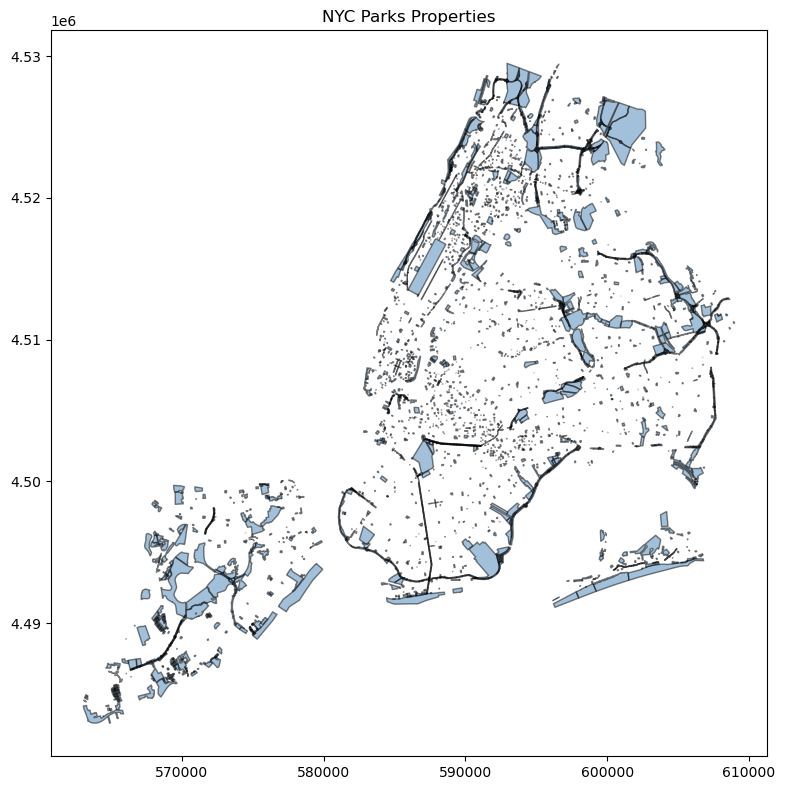

In [22]:
# Set geometry from the WKT multipolygon column
parks_data = parks_data.set_geometry(
    gpd.GeoSeries.from_wkt(parks_data["multipolygon"]), crs="EPSG:4326"
)
parks_data = parks_data.to_crs("EPSG:32618")

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
parks_data.plot(ax=ax, edgecolor="black", facecolor="steelblue", alpha=0.5)
ax.set_title("NYC Parks Properties")
plt.tight_layout()
plt.show()

In [23]:
NY_block_all = gpd.read_file(
    "../Data/drive-download-20260415T180155Z-3-001/nhgis0003_shape/nhgis0003_shape/nhgis0003_shapefile_tl2020_360_block_2020/NY_block_2020.shp"
)
NYC_FIPS = ["005", "047", "061", "081", "085"]
BOROUGH_NAMES = {
    "005": "Bronx",
    "047": "Brooklyn",
    "061": "Manhattan",
    "081": "Queens",
    "085": "Staten Island",
}
nyc_blocks = NY_block_all[NY_block_all["COUNTYFP20"].isin(NYC_FIPS)].copy()
nyc_blocks["borough"] = nyc_blocks["COUNTYFP20"].map(BOROUGH_NAMES)

# Dissolve blocks to create borough-level geometries
nyc_boundary = nyc_blocks.dissolve().to_crs("EPSG:32618")
nyc_boundary.to_file("nyc_boundary.geojson", driver="GeoJSON")

In [24]:
# --- Build raster grid ---
resolution = 100  # meters per pixel
minx, miny, maxx, maxy = nyc_boundary.total_bounds
width = int((maxx - minx) / resolution)
height = int((maxy - miny) / resolution)
transform = from_bounds(minx, miny, maxx, maxy, width, height)

# --- Rasterize parks & boundary ---
park_mask = rasterize(
    shapes=parks_data.geometry,
    out_shape=(height, width),
    transform=transform,
    fill=0,
    default_value=1,
    dtype="uint8",
)

nyc_mask = rasterize(
    shapes=nyc_boundary.geometry,
    out_shape=(height, width),
    transform=transform,
    fill=0,
    default_value=1,
    dtype="uint8",
)

In [25]:
# --- Distance transform ---
parks_distance_meters = distance_transform_edt(1 - park_mask) * resolution
parks_distance_meters[nyc_mask == 0] = np.nan

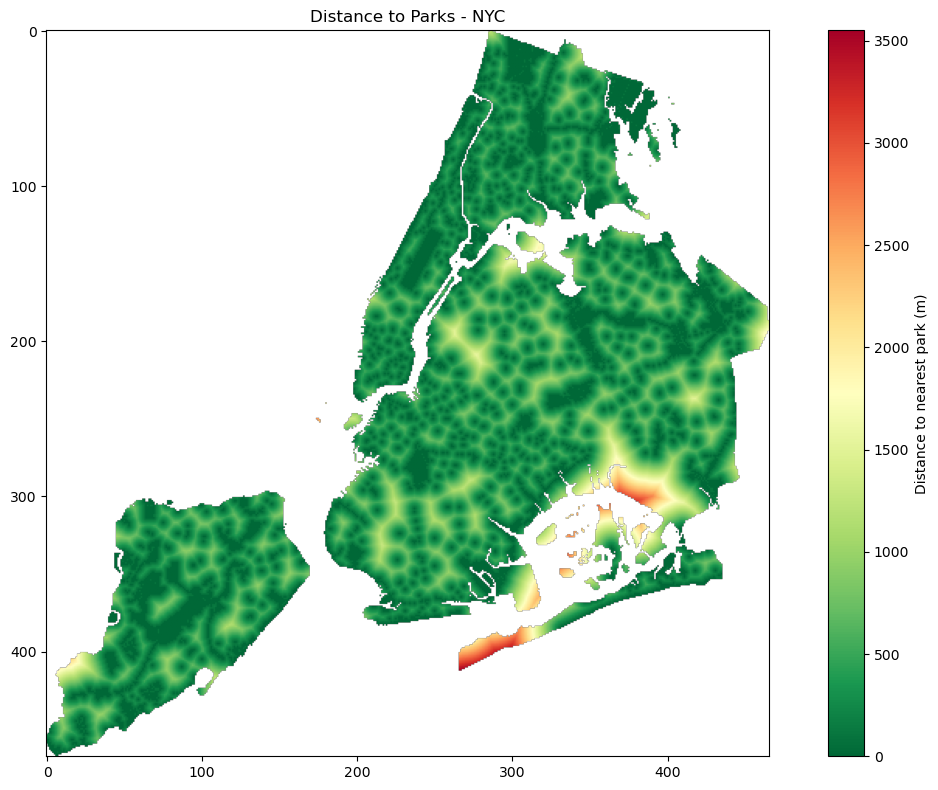

In [26]:
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(parks_distance_meters, cmap="RdYlGn_r")
plt.colorbar(im, ax=ax, label="Distance to nearest park (m)")
ax.set_title("Distance to Parks - NYC")
plt.tight_layout()
plt.show()

In [27]:
with rasterio.open(
    "../Data/distance_to_parks.tif",
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype="float32",
    crs="EPSG:32618",
    transform=transform,
    nodata=np.nan,
) as dst:
    dst.write(parks_distance_meters.astype("float32"), 1)

In [28]:
from rasterstats import zonal_stats

# Make sure blocks are in the same CRS as the raster
nyc_blocks_utm = nyc_blocks.to_crs("EPSG:32618")

# Compute mean distance to park for each block
stats = zonal_stats(
    nyc_blocks_utm,
    "../Data/distance_to_parks.tif",
    stats=["mean", "min", "max"],
    nodata=np.nan,
)

In [29]:
nyc_blocks_utm["mean_dist_to_park"] = [s["mean"] for s in stats]
nyc_blocks_utm["min_dist_to_park"] = [s["min"] for s in stats]

In [30]:
nyc_blocks_utm

,GISJOIN,STATEFP20,COUNTYFP20,TRACTCE20,BLOCKCE20,GEOID20,NAME20,MTFCC20,UR20,UACE20,...,ALAND20,AWATER20,INTPTLAT20,INTPTLON20,Shape_Leng,Shape_Area,geometry,borough,mean_dist_to_park,min_dist_to_park
8019,G36000500001001000,36,005,000100,1000,360050001001000,Block 1000,G5040,None,None,...,469092.0,0.0,+40.7892377,-073.8773641,6830.156709,469092.698143,"POLYGON ((594050.21 4515675.115, 594060.573 45...",Bronx,1536.397529,700.000000
8020,G36000500001001001,36,005,000100,1001,360050001001001,Block 1001,G5040,None,None,...,518008.0,0.0,+40.7909952,-073.8802197,3234.417215,518008.039135,"POLYGON ((594129.294 4515899.618, 594129.076 4...",Bronx,1405.743466,1004.987549
8021,G36000500001001002,36,005,000100,1002,360050001001002,Block 1002,G5040,None,None,...,13148.0,0.0,+40.7914102,-073.8843370,1561.988511,13147.826480,"POLYGON ((594137.199 4516571.541, 594142.722 4...",Bronx,NaN,NaN
8022,G36000500001001003,36,005,000100,1003,360050001001003,Block 1003,G5040,None,None,...,676962.0,0.0,+40.7924981,-073.8882287,3470.500964,676961.813449,"POLYGON ((594128.304 4516594.189, 594124.97 45...",Bronx,757.859258,300.000000
8023,G36000500002001000,36,005,000200,1000,360050002001000,Block 1000,G5040,None,None,...,19130.0,0.0,+40.8141662,-073.8598391,631.791759,19130.472390,"POLYGON ((596181.631 4518858.921, 596219.692 4...",Bronx,299.690165,282.842712
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200455,G36008500323001021,36,085,032300,1021,360850323001021,Block 1021,G5040,None,None,...,37948.0,0.0,+40.6263966,-074.1729102,835.899462,37948.170428,"POLYGON ((569795.677 4497546.276, 569816.059 4...",Staten Island,153.005640,100.000000
200456,G36008500323001022,36,085,032300,1022,360850323001022,Block 1022,G5040,None,None,...,303221.0,0.0,+40.6249418,-074.1704854,2803.882808,303220.113276,"POLYGON ((570487.309 4497726.42, 570469.901 44...",Staten Island,265.503468,0.000000
200457,G36008500323001023,36,085,032300,1023,360850323001023,Block 1023,G5040,None,None,...,3771.0,0.0,+40.6260910,-074.1750220,301.233866,3771.331525,"POLYGON ((569795.677 4497546.276, 569707.245 4...",Staten Island,NaN,NaN
200458,G36008500323001024,36,085,032300,1024,360850323001024,Block 1024,G5040,None,None,...,6655.0,0.0,+40.6258118,-074.1769173,404.289022,6654.695826,"POLYGON ((569616.011 4497502.075, 569553.141 4...",Staten Island,0.000000,0.000000


In [35]:
NYC_waterbodies = gpd.read_file("../Data/NYC_Hydrography.csv")

In [36]:
NYC_waterbodies

,the_geom,NAME,SOURCE_ID,FEAT_CODE,SUB_CODE,STATUS,SHAPE_Leng,SHAPE_Area
0,MULTIPOLYGON (((-74.04707890052428 40.69049105...,unset,"19,265,000,031","2,650","265,000",Unchanged,162.458070583,"1,178.09277425"
1,MULTIPOLYGON (((-73.89995885477707 40.89759588...,unset,"15,261,000,100","2,610","261,000",Unchanged,201.707939876,"2,109.09958816"
2,MULTIPOLYGON (((-73.8199624658045 40.857066702...,unset,"15,264,000,101","2,610","261,000",Updated,803.242781577,"28,720.184387"
3,MULTIPOLYGON (((-73.87561672141112 40.85367606...,unset,"15,261,000,088","2,610","261,000",Unchanged,741.840437909,"9,360.13187674"
4,MULTIPOLYGON (((-73.7898861242589 40.870680368...,unset,"15,264,000,093","2,640","264,000",Unchanged,327.566942186,"4,032.43780654"
...,...,...,...,...,...,...,...,...
2201,MULTIPOLYGON (((-73.8294583911188 40.722108403...,unset,"9,261,000,018","2,610","261,000",Updated,703.116767162,"6,835.35690767"
2202,MULTIPOLYGON (((-73.82904883876944 40.72218279...,unset,"9,261,000,018","2,610","261,000",Updated,273.052281009,"2,590.37039381"
2203,MULTIPOLYGON (((-73.99600999577936 40.70244515...,unset,"21,261,000,001","2,610","261,000",Unchanged,284.939990556,"1,893.02707906"
2204,MULTIPOLYGON (((-73.99656751967987 40.70145514...,unset,"21,261,000,002","2,610","261,000",Unchanged,255.632501094,"2,361.14583007"


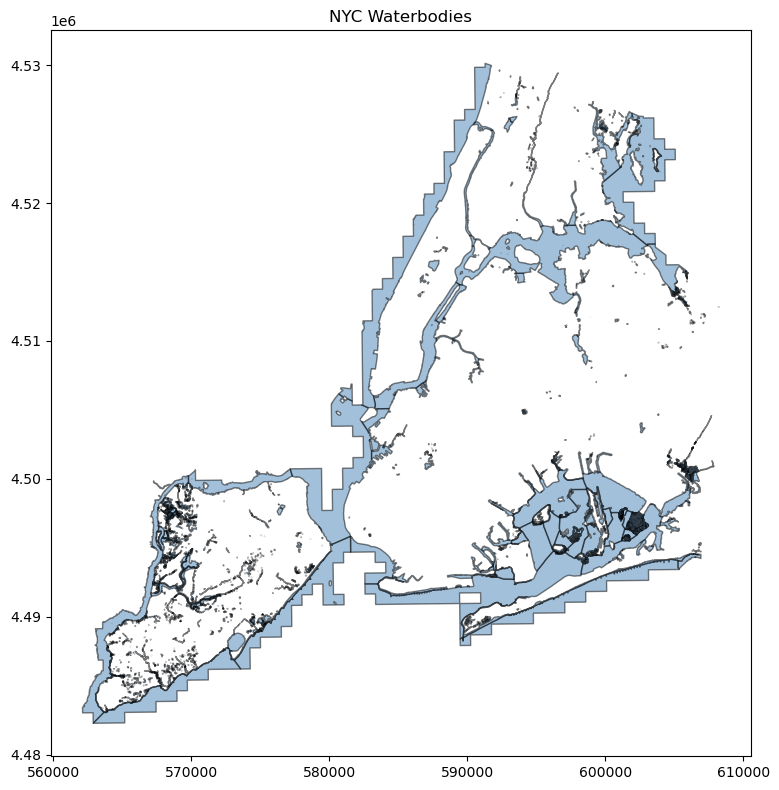

In [37]:
# Set geometry from the WKT multipolygon column
NYC_waterbodies = NYC_waterbodies.set_geometry(
    gpd.GeoSeries.from_wkt(NYC_waterbodies["the_geom"]), crs="EPSG:4326"
)
NYC_waterbodies = NYC_waterbodies.to_crs("EPSG:32618")

# Plot
fig, ax = plt.subplots(figsize=(12, 8))
NYC_waterbodies.plot(ax=ax, edgecolor="black", facecolor="steelblue", alpha=0.5)
ax.set_title("NYC Waterbodies")
plt.tight_layout()
plt.show()

In [38]:
# Use the same grid as before
water_mask = rasterize(
    shapes=NYC_waterbodies.geometry,
    out_shape=(height, width),
    transform=transform,
    fill=0,
    default_value=1,
    dtype="uint8",
)

# --- Distance transform BEFORE applying NYC mask ---
distance_water_meters = distance_transform_edt(1 - water_mask) * resolution

# --- THEN mask to NYC ---
distance_water_meters[nyc_mask == 0] = np.nan

In [40]:
with rasterio.open(
    "../Data/distance_to_water.tif",
    "w",
    driver="GTiff",
    height=height,
    width=width,
    count=1,
    dtype="float32",
    crs="EPSG:32618",
    transform=transform,
    nodata=np.nan,
) as dst:
    dst.write(distance_water_meters.astype("float32"), 1)

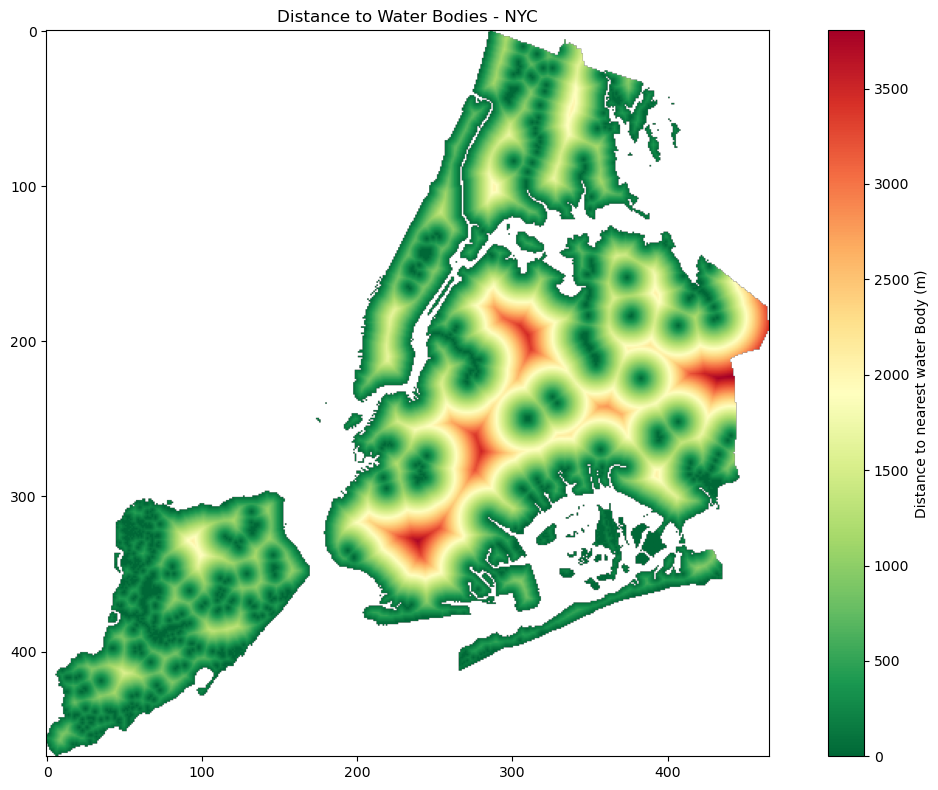

In [42]:
fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(distance_water_meters, cmap="RdYlGn_r")
plt.colorbar(im, ax=ax, label="Distance to nearest water Body (m)")
ax.set_title("Distance to Water Bodies - NYC")
plt.tight_layout()
plt.show()

In [43]:
water_stats = zonal_stats(
    nyc_blocks_utm,
    "../Data/distance_to_parks.tif",
    stats=["mean", "min", "max"],
    nodata=np.nan,
)

nyc_blocks_utm["mean_dist_to_water"] = [sw["mean"] for sw in water_stats]
nyc_blocks_utm["min_dist_to_water"] = [sw["min"] for sw in water_stats]

In [44]:
nyc_blocks_utm

,GISJOIN,STATEFP20,COUNTYFP20,TRACTCE20,BLOCKCE20,GEOID20,NAME20,MTFCC20,UR20,UACE20,...,INTPTLAT20,INTPTLON20,Shape_Leng,Shape_Area,geometry,borough,mean_dist_to_park,min_dist_to_park,mean_dist_to_water,min_dist_to_water
8019,G36000500001001000,36,005,000100,1000,360050001001000,Block 1000,G5040,None,None,...,+40.7892377,-073.8773641,6830.156709,469092.698143,"POLYGON ((594050.21 4515675.115, 594060.573 45...",Bronx,1536.397529,700.000000,1536.397529,700.000000
8020,G36000500001001001,36,005,000100,1001,360050001001001,Block 1001,G5040,None,None,...,+40.7909952,-073.8802197,3234.417215,518008.039135,"POLYGON ((594129.294 4515899.618, 594129.076 4...",Bronx,1405.743466,1004.987549,1405.743466,1004.987549
8021,G36000500001001002,36,005,000100,1002,360050001001002,Block 1002,G5040,None,None,...,+40.7914102,-073.8843370,1561.988511,13147.826480,"POLYGON ((594137.199 4516571.541, 594142.722 4...",Bronx,NaN,NaN,NaN,NaN
8022,G36000500001001003,36,005,000100,1003,360050001001003,Block 1003,G5040,None,None,...,+40.7924981,-073.8882287,3470.500964,676961.813449,"POLYGON ((594128.304 4516594.189, 594124.97 45...",Bronx,757.859258,300.000000,757.859258,300.000000
8023,G36000500002001000,36,005,000200,1000,360050002001000,Block 1000,G5040,None,None,...,+40.8141662,-073.8598391,631.791759,19130.472390,"POLYGON ((596181.631 4518858.921, 596219.692 4...",Bronx,299.690165,282.842712,299.690165,282.842712
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
200455,G36008500323001021,36,085,032300,1021,360850323001021,Block 1021,G5040,None,None,...,+40.6263966,-074.1729102,835.899462,37948.170428,"POLYGON ((569795.677 4497546.276, 569816.059 4...",Staten Island,153.005640,100.000000,153.005640,100.000000
200456,G36008500323001022,36,085,032300,1022,360850323001022,Block 1022,G5040,None,None,...,+40.6249418,-074.1704854,2803.882808,303220.113276,"POLYGON ((570487.309 4497726.42, 570469.901 44...",Staten Island,265.503468,0.000000,265.503468,0.000000
200457,G36008500323001023,36,085,032300,1023,360850323001023,Block 1023,G5040,None,None,...,+40.6260910,-074.1750220,301.233866,3771.331525,"POLYGON ((569795.677 4497546.276, 569707.245 4...",Staten Island,NaN,NaN,NaN,NaN
200458,G36008500323001024,36,085,032300,1024,360850323001024,Block 1024,G5040,None,None,...,+40.6258118,-074.1769173,404.289022,6654.695826,"POLYGON ((569616.011 4497502.075, 569553.141 4...",Staten Island,0.000000,0.000000,0.000000,0.000000


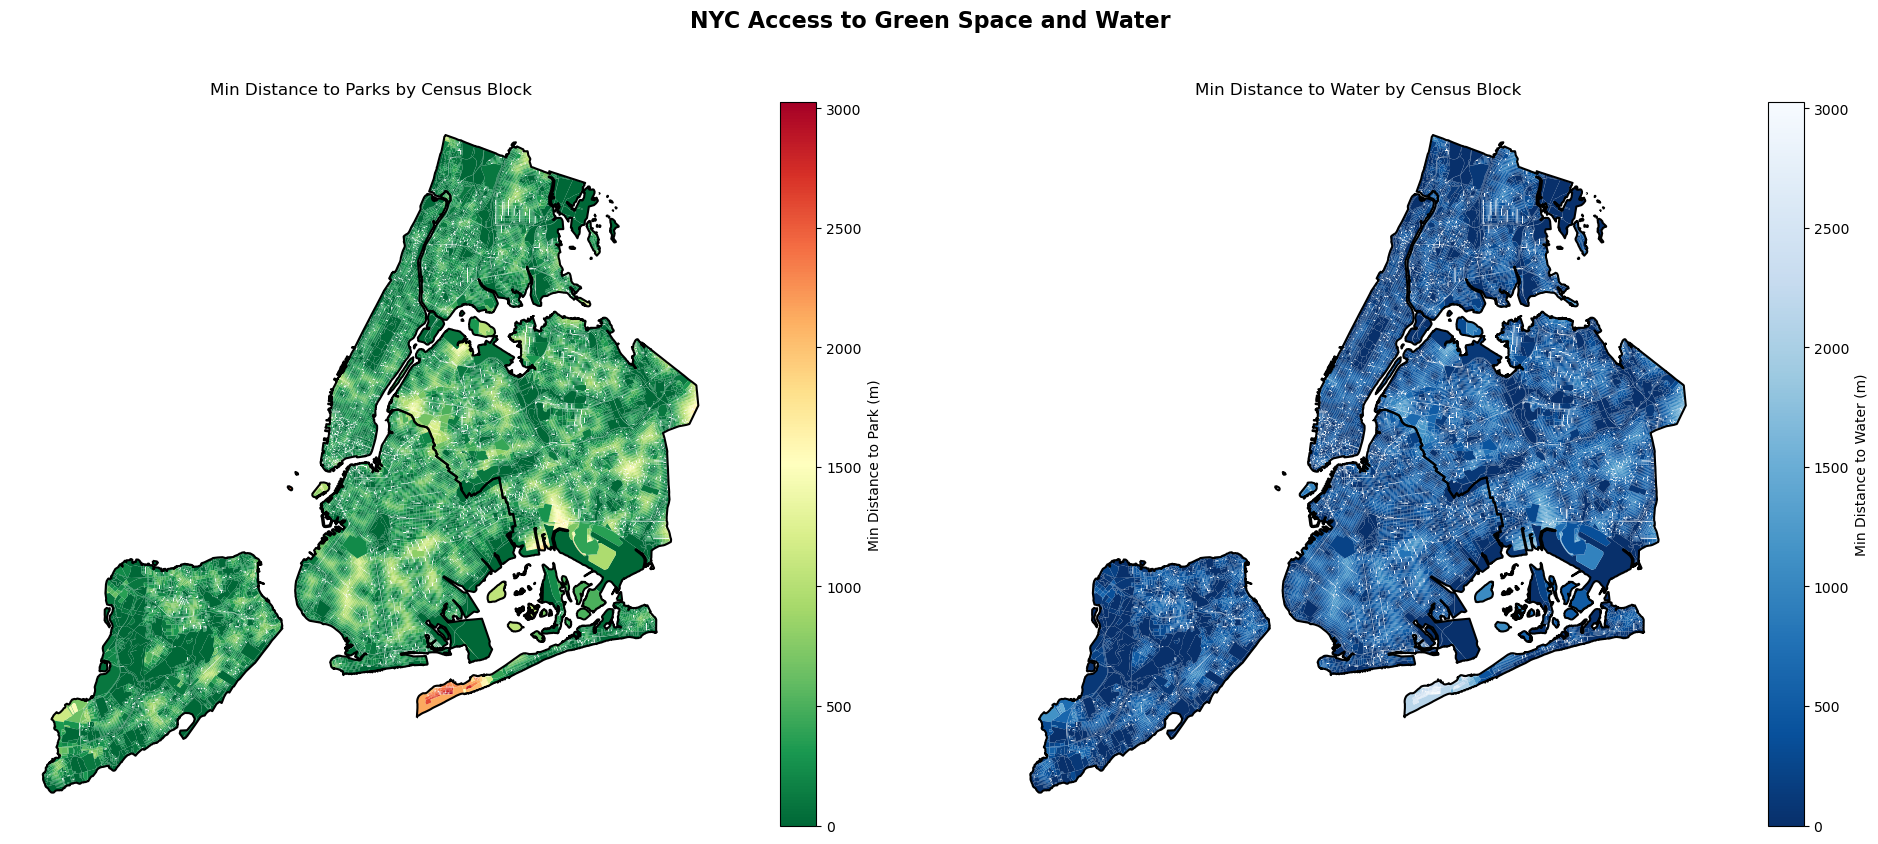

In [49]:
nyc_boroughs_utm = nyc_blocks.dissolve(by="borough").to_crs("EPSG:32618")


fig, axes = plt.subplots(1, 2, figsize=(20, 8))

nyc_blocks_utm.plot(
    column="min_dist_to_park",
    ax=axes[0],
    cmap="RdYlGn_r",
    legend=True,
    legend_kwds={"label": "Min Distance to Park (m)"},
)
nyc_boroughs_utm.boundary.plot(ax=axes[0], edgecolor="black", linewidth=1.5)
axes[0].set_title("Min Distance to Parks by Census Block")
axes[0].set_axis_off()

nyc_blocks_utm.plot(
    column="min_dist_to_water",
    ax=axes[1],
    cmap="Blues_r",
    legend=True,
    legend_kwds={"label": "Min Distance to Water (m)"},
)
nyc_boroughs_utm.boundary.plot(ax=axes[1], edgecolor="black", linewidth=1.5)
axes[1].set_title("Min Distance to Water by Census Block")
axes[1].set_axis_off()

plt.suptitle(
    "NYC Access to Green Space and Water", fontsize=16, fontweight="bold", y=1.05
)
plt.tight_layout()
plt.show()

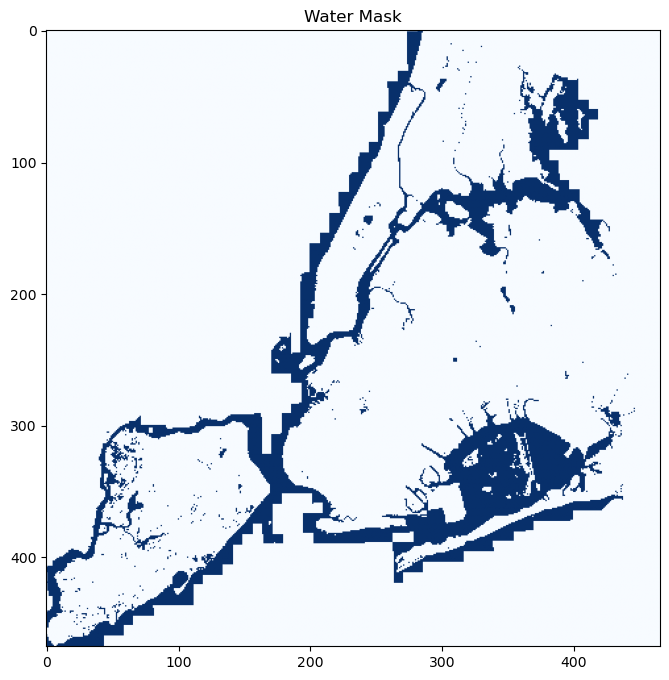

In [48]:
fig, ax = plt.subplots(figsize=(12, 8))
ax.imshow(water_mask, cmap="Blues")
plt.title("Water Mask")
plt.show()

In [51]:
nyc_blocks_utm.to_csv("../Data/NYC_block_temp_water.csv", sep=",")